<a href="https://colab.research.google.com/github/bihjane/Data-science-and-AI-K-12-teaching-tools/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Recognition - Training a Neural Network

## What is MNIST?

MNIST is a dataset of 70,000 handwritten digits (0-9):
- **60,000 training images** - Used to teach the network
- **10,000 test images** - Used to evaluate how well it learned
- Each image is **28×28 pixels** in grayscale (0-255)

This is considered the "Hello World" of deep learning!

## Step 1: Import Libraries

In [ ]:
# Import necessary libraries
from keras.datasets import mnist
from keras import models
from keras import layers
import numpy as np
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

## Step 2: Load the MNIST Dataset

Keras provides MNIST pre-loaded. The data is already split into training and test sets.

In [ ]:
# Load MNIST data - automatically downloads first time
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


## Step 3: Visualize Sample Images

Let's look at some of the handwritten digits in the dataset.

Label: 8


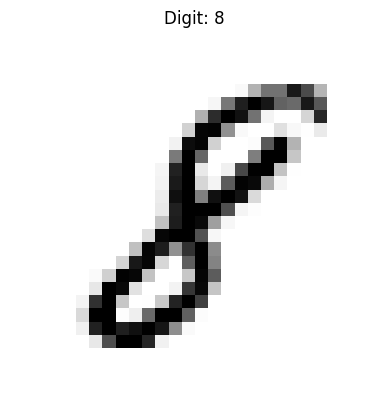

In [ ]:
# Display a single image
image_index = 7777  # Try different values between 0-59999
print(f"Label: {train_labels[image_index]}")
plt.imshow(train_images[image_index], cmap='Greys')
plt.title(f"Digit: {train_labels[image_index]}")
plt.axis('off')
plt.show()

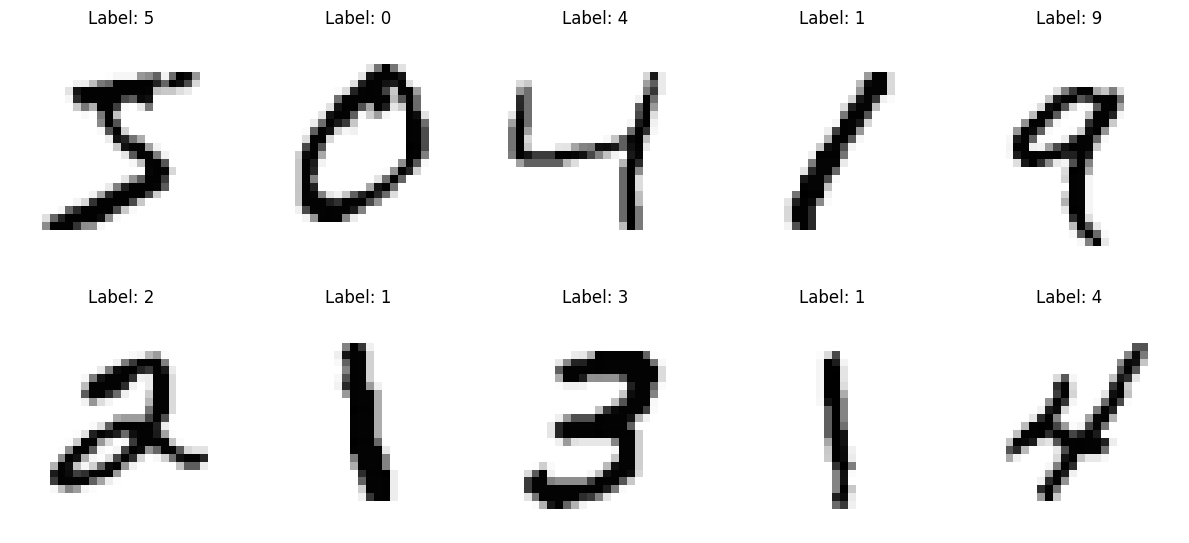

In [ ]:
# Display multiple images in a grid
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='Greys')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Examine Data Structure

Understanding the shape and structure of our data is crucial.

In [ ]:
# Check data details
print("Training set:")
print(f"  Images shape: {train_images.shape}")  # (60000, 28, 28)
print(f"  Labels shape: {train_labels.shape}")  # (60000,)
print(f"  First 10 labels: {train_labels[:10]}")
print(f"  Pixel value range: {train_images.min()} to {train_images.max()}")
print()
print("Test set:")
print(f"  Images shape: {test_images.shape}")   # (10000, 28, 28)
print(f"  Labels shape: {test_labels.shape}")   # (10000,)

Training set:
  Images shape: (60000, 28, 28)
  Labels shape: (60000,)
  First 10 labels: [5 0 4 1 9 2 1 3 1 4]
  Pixel value range: 0 to 255

Test set:
  Images shape: (10000, 28, 28)
  Labels shape: (10000,)


## Step 5: Preprocess the Data

### 5a. Reshape the Data

We need to flatten each 28×28 image into a 1D array of 784 values.

In [ ]:
# Reshape from (samples, 28, 28) to (samples, 784)
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))

print(f"Training images reshaped: {train_images.shape}")
print(f"Test images reshaped: {test_images.shape}")

Training images reshaped: (60000, 784)
Test images reshaped: (10000, 784)


### 5b. Normalize Pixel Values

Convert pixel values from 0-255 to 0-1 range for better neural network performance.

In [ ]:
# Normalize: divide by 255 to get values between 0 and 1
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

print(f"After normalization - Min: {train_images.min()}, Max: {train_images.max()}")

After normalization - Min: 0.0, Max: 1.0


### 5c. Convert Labels to Categorical (One-Hot Encoding)

Convert integer labels (0-9) to binary vectors.

Example: Label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

In [ ]:
# Show labels before conversion
print("Before one-hot encoding:")
print(f"First 10 labels: {train_labels[:10]}")
print()

# Convert to categorical
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print("After one-hot encoding:")
print(f"Labels shape: {train_labels.shape}")
print(f"First label: {train_labels[0]}")
print(f"This represents digit: {np.argmax(train_labels[0])}")

Before one-hot encoding:
First 10 labels: [5 0 4 1 9 2 1 3 1 4]

After one-hot encoding:
Labels shape: (60000, 10)
First label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
This represents digit: 5


## Step 6: Build the Neural Network

We'll create a simple neural network with:
- Input layer: 784 neurons (one per pixel)
- Hidden layer: 512 neurons with ReLU activation
- Output layer: 10 neurons (one per digit) with softmax activation

In [ ]:
# Create the network architecture
network = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28 * 28,)),
    layers.Dense(10, activation='softmax')
])

# Display the network architecture
network.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile the Network

Configure the learning process:
- **Optimizer**: rmsprop (adjusts weights during training)
- **Loss function**: categorical_crossentropy (measures prediction error)
- **Metrics**: accuracy (tracks performance)

In [ ]:
network.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 8: Train the Network

Train for 5 epochs (5 complete passes through the training data).

In [ ]:
# Train the network
history = network.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.2  # Use 20% of training data for validation
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8585 - loss: 0.4837 - val_accuracy: 0.9578 - val_loss: 0.1463
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9622 - loss: 0.1334 - val_accuracy: 0.9684 - val_loss: 0.1066
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9771 - loss: 0.0788 - val_accuracy: 0.9732 - val_loss: 0.0912
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9830 - loss: 0.0576 - val_accuracy: 0.9756 - val_loss: 0.0798
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9876 - loss: 0.0413 - val_accuracy: 0.9774 - val_loss: 0.0769


## Step 9: Evaluate the Model

Test the trained network on unseen test data.

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = network.evaluate(test_images, test_labels)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0764

Test Accuracy: 98.04%
Test Loss: 0.0663


## Step 10: Visualize Training Progress

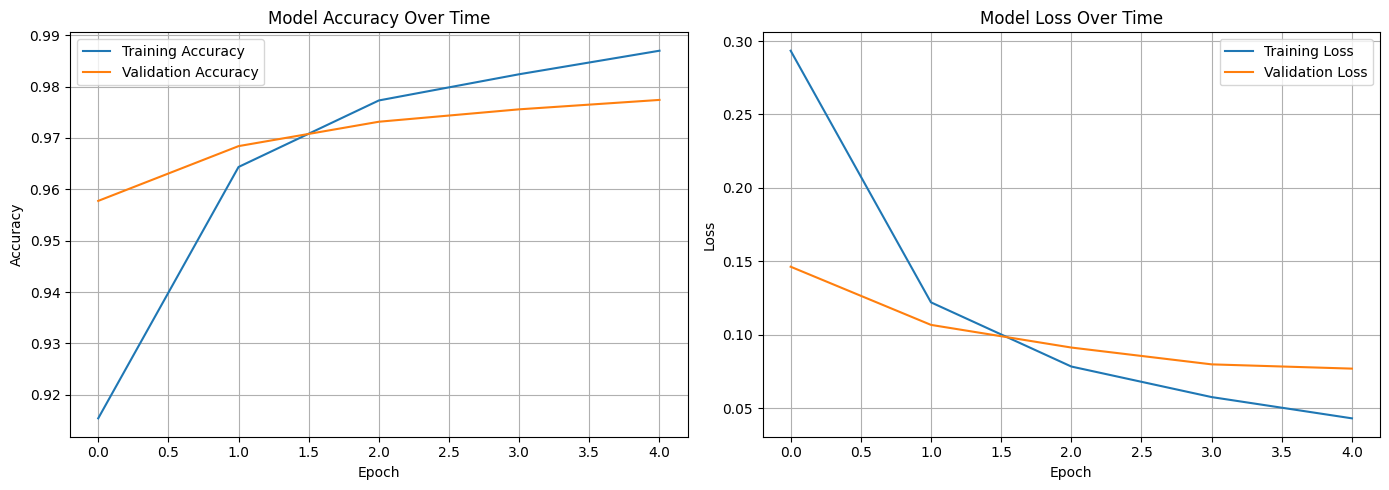

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Step 11: Save the Model

Save the trained model for later use in the exploration notebook.

In [ ]:
# Save the trained model
model.save('mnist_model.h5')
print("Model saved as 'mnist_model.h5'")

NameError: name 'model' is not defined

## Summary

We successfully:
1. Loaded the MNIST dataset
2. Preprocessed the data (reshape, normalize, one-hot encode)
3. Built a neural network with 784 inputs → 512 hidden neurons → 10 outputs
4. Trained the network for 5 epochs
5. Achieved high accuracy on the test set
6. Saved the model for future use

**Next:** Use the saved model in the MNIST_Explored notebook to analyze predictions!